<a href="https://colab.research.google.com/github/xyz111131/AI-Tools-for-Statistical-Research/blob/main/Matrix_multiply_bench_mark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  import cupy as cp

ModuleNotFoundError: No module named 'cupy'

In [1]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    import cupy as cp
    cupy_installed = True
except ImportError:
    print("CuPy not found. Installing CuPy. This might take a few minutes.")
    !pip install cupy-cuda11x # Install CuPy for CUDA 11.x, adjust if needed
    try:
        import cupy as cp
        cupy_installed = True
    except ImportError:
        print("CuPy installation failed or incompatible CUDA version. CuPy benchmarks will be skipped.")
        cupy_installed = False

print(f"CUDA available for PyTorch: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"PyTorch CUDA device name: {torch.cuda.get_device_name(0)}")

if cupy_installed:
    print(f"CuPy available: {cp.cuda.is_available()}")

CUDA available for PyTorch: True
PyTorch CUDA device name: Tesla T4
CuPy available: True


AttributeError: 'cupy.cuda.device.Device' object has no attribute 'name'

Next, let's define a function to benchmark matrix multiplication for different libraries and devices.

In [10]:
def benchmark_matrix_mult(library, device, size, num_runs=50):
    if library == 'numpy':
        if device == 'cpu':
            a = np.random.rand(size, size)
            b = np.random.rand(size, size)
            start_time = time.time()
            for _ in range(num_runs):
                np.dot(a, b)
            end_time = time.time()
            return (end_time - start_time) / num_runs
        else:
            return None # NumPy is CPU-only

    elif library == 'torch':
        if device == 'cpu':
            a = torch.randn(size, size, device='cpu')
            b = torch.randn(size, size, device='cpu')
            start_time = time.time()
            for _ in range(num_runs):
                torch.matmul(a, b)
            end_time = time.time()
            return (end_time - start_time) / num_runs
        elif device == 'gpu' and torch.cuda.is_available():
            a = torch.randn(size, size, device='cuda')
            b = torch.randn(size, size, device='cuda')
            # Warm-up for GPU
            for _ in range(5):
                torch.matmul(a, b)
            torch.cuda.synchronize()
            start_time = time.time()
            for _ in range(num_runs):
                torch.matmul(a, b)
            torch.cuda.synchronize()
            end_time = time.time()
            return (end_time - start_time) / num_runs
        else:
            return None

    elif library == 'cupy':
        if cupy_installed and device == 'gpu' and cp.cuda.is_available():
            a = cp.random.rand(size, size)
            b = cp.random.rand(size, size)
            # Warm-up for GPU
            for _ in range(5):
                cp.dot(a, b)
            cp.cuda.Stream.null.synchronize()
            start_time = time.time()
            for _ in range(num_runs):
                cp.dot(a, b)
            cp.cuda.Stream.null.synchronize()
            end_time = time.time()
            return (end_time - start_time) / num_runs
        else:
            return None

    return None

Now that we have defined the benchmarking function, let's run some benchmarks for different matrix sizes and libraries. We'll compare NumPy (CPU), PyTorch (CPU and GPU), and CuPy (GPU).

In [11]:
import pandas as pd

sizes = [128, 256, 512, 1024, 2048]
results = []

for size in sizes:
    print(f"Benchmarking for matrix size: {size}x{size}")

    # NumPy CPU
    numpy_cpu_time = benchmark_matrix_mult('numpy', 'cpu', size)
    if numpy_cpu_time is not None:
        results.append({'Library': 'NumPy', 'Device': 'CPU', 'Size': size, 'Time (s)': numpy_cpu_time})

    # PyTorch CPU
    torch_cpu_time = benchmark_matrix_mult('torch', 'cpu', size)
    if torch_cpu_time is not None:
        results.append({'Library': 'PyTorch', 'Device': 'CPU', 'Size': size, 'Time (s)': torch_cpu_time})

    # PyTorch GPU
    if torch.cuda.is_available():
        torch_gpu_time = benchmark_matrix_mult('torch', 'gpu', size)
        if torch_gpu_time is not None:
            results.append({'Library': 'PyTorch', 'Device': 'GPU', 'Size': size, 'Time (s)': torch_gpu_time})

    # CuPy GPU
    if cupy_installed and cp.cuda.is_available():
        cupy_gpu_time = benchmark_matrix_mult('cupy', 'gpu', size)
        if cupy_gpu_time is not None:
            results.append({'Library': 'CuPy', 'Device': 'GPU', 'Size': size, 'Time (s)': cupy_gpu_time})

df_results = pd.DataFrame(results)
display(df_results)

Benchmarking for matrix size: 128x128
Benchmarking for matrix size: 256x256
Benchmarking for matrix size: 512x512
Benchmarking for matrix size: 1024x1024
Benchmarking for matrix size: 2048x2048


,Library,Device,Size,Time (s)
0,NumPy,CPU,128,0.000117
1,PyTorch,CPU,128,0.000054
2,PyTorch,GPU,128,0.000018
3,CuPy,GPU,128,0.000250
4,NumPy,CPU,256,0.000689
5,PyTorch,CPU,256,0.000400
6,PyTorch,GPU,256,0.000050
7,CuPy,GPU,256,0.000495
8,NumPy,CPU,512,0.005091
9,PyTorch,CPU,512,0.002873


Let's visualize the benchmark results to better understand the performance differences.

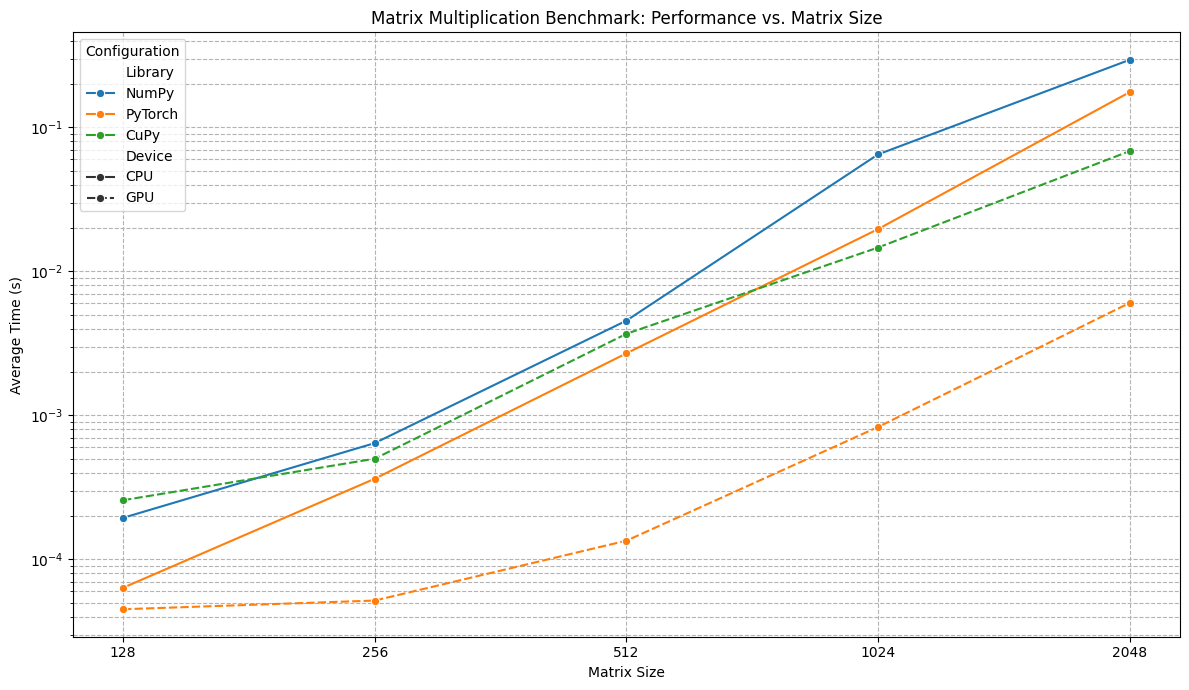

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_results, x='Size', y='Time (s)', hue='Library', style='Device', marker='o')
plt.title('Matrix Multiplication Benchmark: Performance vs. Matrix Size')
plt.xlabel('Matrix Size')
plt.ylabel('Average Time (s)')
plt.xscale('log', base=2) # Use log scale for x-axis if sizes span a large range
plt.yscale('log') # Use log scale for y-axis to better visualize differences in smaller values
plt.xticks(df_results['Size'].unique(), labels=df_results['Size'].unique())
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Configuration')
plt.tight_layout()
plt.show()